# Real-Data Small-Sample Benchmark

Benchmark QML implementations against classical baselines on the small real datasets exposed by the package. These runs use only the package-selected feature subset, so interpret them as controlled small-feature comparisons rather than broad real-world claims.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "qml").exists():
    repo_root = next(
        (parent for parent in repo_root.parents if (parent / "src" / "qml").exists()),
        repo_root,
    )
package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

In [2]:
from qml.benchmarks import compare_classification_models, compare_regression_models
from qml.reporting import print_table
import matplotlib.pyplot as plt

In [3]:
CONFIG = {
    "seeds": [0],
    "n_samples": 60,
    "noise": 0.0,
    "test_size": 0.25,
    "tune_classical": False,
}

classification_datasets = ["breast_cancer", "wine"]
regression_datasets = ["diabetes"]

In [4]:
def add_classification_rows(dataset, result):
    return [
        {
            "dataset": dataset,
            "model": model,
            "test_accuracy": stats["test_accuracy"]["mean"],
            "ci95_low": stats["test_accuracy"]["ci95_low"],
            "ci95_high": stats["test_accuracy"]["ci95_high"],
            "gap": stats["generalization_gap"]["mean"],
            "runtime_s": stats["runtime_seconds"]["mean"],
        }
        for model, stats in result["summary"].items()
    ]


def add_regression_rows(dataset, result):
    return [
        {
            "dataset": dataset,
            "model": model,
            "test_mse": stats["test_mse"]["mean"],
            "test_mae": stats["test_mae"]["mean"],
            "ci95_low": stats["test_mse"]["ci95_low"],
            "ci95_high": stats["test_mse"]["ci95_high"],
            "runtime_s": stats["runtime_seconds"]["mean"],
        }
        for model, stats in result["summary"].items()
    ]

## Classification

In [5]:
classification_rows = []

for dataset in classification_datasets:
    result = compare_classification_models(
        models=["vqc", "quantum_kernel", "quantum_reservoir", "logistic_regression", "svm_classifier"],
        seeds=CONFIG["seeds"],
        n_samples=CONFIG["n_samples"],
        noise=CONFIG["noise"],
        test_size=CONFIG["test_size"],
        dataset=dataset,
        tune_classical=CONFIG["tune_classical"],
        model_kwargs={
            "vqc": {"n_layers": 1, "steps": 4},
            "quantum_reservoir": {"n_layers": 1},
        },
        save=False,
    )
    classification_rows.extend(add_classification_rows(dataset, result))

print_table(sorted(classification_rows, key=lambda row: (row["dataset"], -row["test_accuracy"])), title="Real-data classification summary")

Real-data classification summary
+---------------+---------------------+---------------+----------+-----------+------------+------------+
| dataset       | model               | test_accuracy | ci95_low | ci95_high | gap        | runtime_s  |
+---------------+---------------------+---------------+----------+-----------+------------+------------+
| breast_cancer | logistic_regression | 0.8           | 0.8      | 0.8       | 0.0666667  | 0.0089817  |
| breast_cancer | quantum_kernel      | 0.666667      | 0.666667 | 0.666667  | 0.2        | 3.01411    |
| breast_cancer | svm_classifier      | 0.666667      | 0.666667 | 0.666667  | 0.2        | 0.0115813  |
| breast_cancer | vqc                 | 0.533333      | 0.533333 | 0.533333  | -0.0666667 | 1.37249    |
| breast_cancer | quantum_reservoir   | 0.466667      | 0.466667 | 0.466667  | 0.177778   | 0.201987   |
| wine          | quantum_kernel      | 1             | 1        | 1         | -0.0888889 | 2.95942    |
| wine          | svm_

## Classification Plot

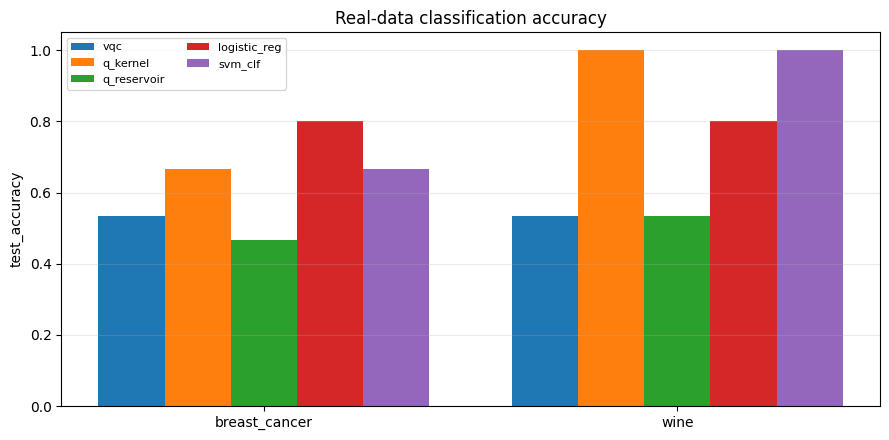

In [6]:

import matplotlib.pyplot as plt


def _short_label(label):
    return label.replace("quantum_", "q_").replace("_regression", "_reg").replace("_classifier", "_clf")


def plot_metric_bars(rows, metric, title, *, lower_is_better=False):
    ordered = sorted(rows, key=lambda row: row[metric], reverse=not lower_is_better)
    labels = [_short_label(row["model"]) for row in ordered]
    values = [row[metric] for row in ordered]
    errors = [
        [max(0.0, row[metric] - row.get("ci95_low", row[metric])) for row in ordered],
        [max(0.0, row.get("ci95_high", row[metric]) - row[metric]) for row in ordered],
    ]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(labels, values, yerr=errors, capsize=4, color="#3b82f6", edgecolor="#1f2937", linewidth=0.7)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()


def plot_runtime_scatter(rows, metric, title, *, lower_is_better=False):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for row in rows:
        ax.scatter(row["runtime_s"], row[metric], s=70)
        ax.annotate(_short_label(row["model"]), (row["runtime_s"], row[metric]), xytext=(5, 4), textcoords="offset points", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("mean runtime (s)")
    ax.set_ylabel(metric)
    if lower_is_better:
        ax.invert_yaxis()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()


def plot_dataset_bars(rows, metric, title, *, lower_is_better=False):
    datasets = list(dict.fromkeys(row["dataset"] for row in rows))
    models = list(dict.fromkeys(row["model"] for row in rows))
    width = 0.8 / max(1, len(models))
    x = list(range(len(datasets)))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for index, model in enumerate(models):
        values = []
        for dataset in datasets:
            match = next((row for row in rows if row["dataset"] == dataset and row["model"] == model), None)
            values.append(float("nan") if match is None else match[metric])
        offsets = [position - 0.4 + width / 2 + index * width for position in x]
        ax.bar(offsets, values, width=width, label=_short_label(model))
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xticks(x, datasets)
    if lower_is_better:
        ax.invert_yaxis()
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=8, ncols=2)
    fig.tight_layout()
    plt.show()

plot_dataset_bars(classification_rows, "test_accuracy", "Real-data classification accuracy")

## Regression

In [7]:
regression_rows = []

for dataset in regression_datasets:
    result = compare_regression_models(
        models=["vqr", "quantum_kernel_regressor", "quantum_reservoir_regressor", "ridge_regression", "svr_regression"],
        seeds=CONFIG["seeds"],
        n_samples=CONFIG["n_samples"],
        noise=CONFIG["noise"],
        test_size=CONFIG["test_size"],
        dataset=dataset,
        tune_classical=CONFIG["tune_classical"],
        model_kwargs={
            "vqr": {"n_layers": 1, "steps": 5},
            "quantum_reservoir_regressor": {"n_layers": 1},
        },
        save=False,
    )
    regression_rows.extend(add_regression_rows(dataset, result))

print_table(sorted(regression_rows, key=lambda row: (row["dataset"], row["test_mse"])), title="Real-data regression summary")

Real-data regression summary
+----------+-----------------------------+----------+----------+----------+-----------+------------+
| dataset  | model                       | test_mse | test_mae | ci95_low | ci95_high | runtime_s  |
+----------+-----------------------------+----------+----------+----------+-----------+------------+
| diabetes | quantum_kernel_regressor    | 0.949192 | 0.85899  | 0.949192 | 0.949192  | 1.57759    |
| diabetes | ridge_regression            | 0.992731 | 0.913113 | 0.992731 | 0.992731  | 0.00436451 |
| diabetes | svr_regression              | 1.09356  | 0.963873 | 1.09356  | 1.09356   | 0.00504524 |
| diabetes | quantum_reservoir_regressor | 1.24796  | 1.03509  | 1.24796  | 1.24796   | 0.176436   |
| diabetes | vqr                         | 1.62663  | 1.01501  | 1.62663  | 1.62663   | 1.67081    |
+----------+-----------------------------+----------+----------+----------+-----------+------------+



## Regression Plot

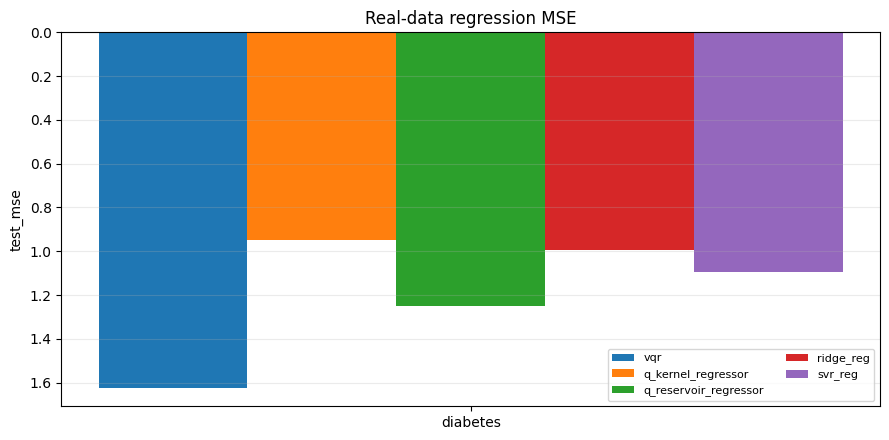

In [8]:
plot_dataset_bars(regression_rows, "test_mse", "Real-data regression MSE", lower_is_better=True)